<a target="_blank" href="https://colab.research.google.com/github/ddefbcourses/assignment-09-mlp/blob/main/notebooks/assignment.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

Nesta versão da atividade utilizaremos o dataset CIFAR-100.

Características do dataset:

- 60.000 imagens RGB
- 100 classes
- imagens 32×32
- 3 canais de cor

Importante:

O carregamento do dataset pode ser realizado utilizando:

```python
from tensorflow.keras.datasets import cifar100

(X_train, y_train), (X_test, y_test) = cifar10.load_data()
```

Após o carregamento:

```python
print(X_train.shape)
```

Saída esperada:

```python
(50000, 32, 32, 3)
```

Onde:

- 50000 - número de imagens;
- 32 × 32 - dimensão espacial;
- 3 - canais RGB.

Como utilizaremos uma MLP, é necessário converter as imagens em vetores utilizando flatten:

```python
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)
```

Após o flatten:

```python
print(X_train.shape)
```

Saída esperada:

```python
(50000, 3072)
```

Isso ocorre porque:

```python
32 × 32 × 3 = 3072
```

# Questão 1

Implemente uma função `load_data(seed)` que:

- carregue o dataset CIFAR-100 utilizando `tensorflow.keras.datasets.cifar100.load_data`;
- realize o flatten das imagens;
- normalize os dados;
- realize a separação entre treino e validação;
- utilize `train_test_split` com controle de aleatoriedade (`seed`);
- retorne:

```python
X_train, X_val, y_train, y_val
```

já normalizados e preparados para treinamento.

Além disso, responda:

1. Qual o formato original das imagens?
2. Quantas features cada imagem possui após o flatten?
3. Por que o flatten é necessário para uma MLP?
4. Qual a importância da normalização para o treinamento?

**Solução**:

In [1]:
# TODO: implemente
import warnings

warnings.filterwarnings("ignore")

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlflow

In [3]:
mlflow.set_experiment(
    "assignment"
)

<Experiment: artifact_location='file:///d:/atividade-05-deep-learning-ii-FelipeARFranca/notebooks/mlruns/602401785620544518', creation_time=1779839792254, experiment_id='602401785620544518', last_update_time=1779839792254, lifecycle_stage='active', name='assignment', tags={}>

In [4]:
from pathlib import Path
import sys

# Procura a pasta src subindo a partir do diretório atual
current_path = Path().resolve()

for parent in [current_path] + list(current_path.parents):
    src_path = parent / "src"
    if src_path.exists():
        sys.path.append(str(src_path))
        break

from experiment import measure_training_time
from metrics import classification_metrics, show_classification_report, compute_confusion_matrix
from plots import plot_training_curve, plot_confusion_matrix, compare_models
from utils import set_seed, print_section, normalize_images

In [5]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
from tensorflow.keras.datasets import cifar100
from sklearn.model_selection import train_test_split

def load_data(seed=42, val_size=0.2):

    (X_train_full, y_train_full), (X_test, y_test) = cifar100.load_data()

    X_train_full = X_train_full.reshape(X_train_full.shape[0], -1)
    X_test = X_test.reshape(X_test.shape[0], -1)

    X_train_full = X_train_full.astype("float32") / 255.0
    X_test = X_test.astype("float32") / 255.0


    y_train_full = y_train_full.ravel()
    y_test = y_test.ravel()


    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full,
        y_train_full,
        test_size=val_size,
        random_state=seed,
        stratify=y_train_full
    )

    return X_train, X_val, y_train, y_val

Resposta: O formato original das imagens do dataset é 32 x 32 pixels e 3 canais de cor RGB. Após o flatten, cada imagem passa a ter 3072 features. O flatten é necessário, pois a MLP recebe a entrada com vetor 1D. As imagens, originalmente em formato de matriz, precisam ser convertidas para uma sequência de valores para que o modelo possa processá-las. A normalização ajuda o treinamento ficar mais estável e eficiênte.

# Questão 2

Implemente a função:

```python
train_mlp(
    X_train,
    y_train,
    activation,
    hidden_layers,
    learning_rate,
    seed
)
```

## Requisitos

Sua implementação deve:

- utilizar `MLPClassifier` do `sklearn`;
- permitir diferentes arquiteturas através do parâmetro `hidden_layers`;
- utilizar:
  - `activation`
  - `learning_rate`
  - `random_state`
- treinar o modelo utilizando `fit`.

A função deve retornar o modelo treinado.

Além disso, responda:

1. Quantos parâmetros existem na primeira camada?
2. Qual a função da ativação ReLU?
3. Por que MLPs possuem muitos parâmetros ao trabalhar com imagens?

**Solução**:

In [7]:
# TODO: implemente
import mlflow
import pandas as pd
from sklearn.neural_network import MLPClassifier

def train_mlp(
    X_train,
    y_train,
    activation,
    hidden_layers,
    learning_rate,
    seed,
    max_iter=100,
    batch_size=32
):
    model = MLPClassifier(
        hidden_layer_sizes=hidden_layers,
        activation=activation,
        learning_rate_init=learning_rate,
        random_state=seed,
        max_iter=max_iter,
        batch_size=batch_size
    )
    model.fit(X_train, y_train)
    return model

Resposta: A quantidade de parâmetros na primeira camada vai depender do número de neurônios: (3072 x No Pesos) + No vieses. A ReLU introduz não linearidade no modelo, ajudando o modelo a aprender padrões complexos. As MLPs possuem muitos parâmetros ao trabalhar com imagens porque, após o flatten, as imagens viram vetores muito grandes.

# Questão 3

Implemente a função:

```python
evaluate(model, X_test, y_test)
```

Ela deve:

- realizar predições;
- calcular:
  - accuracy;
  - precision;
  - recall;
  - f1-score.

Utilize `sklearn.metrics`.

Além disso:

- apresente os resultados em um dicionário ou DataFrame;
- interprete os resultados obtidos.

Responda:

1. O que a accuracy representa?
2. Qual a diferença entre precision e recall?
3. Em quais situações o f1-score é importante?

**Solução**:

In [8]:
# TODO: implemente load_data
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)

    results = classification_metrics(y_test, y_pred)
    results_df = pd.DataFrame([results])

    return results, results_df

Respostas: A accuracy representa a proporção de exemplos que o modelo classificou corretamente em relação ao total de exemplos avaliados. Precision avalia o quão preciso é o modelo com verdadeiros positivos em relação a falsos positivos e Recall avalia a capacidade do modelo de identificar os verdadeiros positivos. O f1-score é importante quando se quer um equilíbrio entre precision e recall. Muitos falsos positivos ou falsos negativos tem impacto semelhante no desempenho no modelo.

**Adicione seu texto de solução aqui**.

# Questão 4

Implemente o rastreamento experimental utilizando MLflow.

## Devem ser registrados:

### Parâmetros

- activation
- hidden_layers
- learning_rate
- max_iter
- batch_size

### Métricas

- accuracy
- precision
- recall
- f1_score
- training_time

Utilize:

```python
mlflow.log_param()
mlflow.log_metric()
```

Ao final:

- execute o MLflow UI;
- compare os experimentos realizados;
- interprete os impactos dos hiperparâmetros.

Responda:

1. Qual experimento apresentou melhor desempenho?
2. Qual configuração apresentou maior estabilidade?
3. Qual o benefício do rastreamento experimental?

**Solução**:

In [9]:
# TODO: implemente
import mlflow

def run_mlp_experiment(
    X_train,
    y_train,
    X_val,
    y_val,
    activation,
    hidden_layers,
    learning_rate,
    seed,
    max_iter=100,
    batch_size=32
):
    with mlflow.start_run():
        mlflow.log_param("activation", activation)
        mlflow.log_param("hidden_layers", str(hidden_layers))
        mlflow.log_param("learning_rate", learning_rate)
        mlflow.log_param("max_iter", max_iter)
        mlflow.log_param("batch_size", batch_size)

        model, training_time = measure_training_time(
            train_mlp,
            X_train,
            y_train,
            activation,
            hidden_layers,
            learning_rate,
            seed,
            max_iter,
            batch_size
        )

        metrics_dict, metrics_df = evaluate(model, X_val, y_val)
        metrics_dict["training_time"] = training_time
        metrics_df["training_time"] = training_time

        for metric_name, metric_value in metrics_dict.items():
            mlflow.log_metric(metric_name, metric_value)

        return model, metrics_dict, metrics_df

# Questão 5

Compare as funções:

- logistic
- tanh
- relu

## Requisitos

Utilize:

- mesma arquitetura;
- mesmo learning rate;
- mesma seed.

Para cada experimento:

- treine o modelo;
- avalie o modelo;
- registre no MLflow.

Depois compare:

- accuracy;
- convergência;
- estabilidade.

Responda:

1. Qual ativação apresentou melhor convergência?
2. Qual ativação apresentou maior estabilidade?
3. Houve diferenças significativas no treinamento?
4. Por que a ReLU é amplamente utilizada em Deep Learning?

**Solução**:

In [10]:
# TODO: implemente
def run_activation_comparison(
    X_train,
    y_train,
    X_val,
    y_val,
    hidden_layers=(128, 64),
    learning_rate=0.001,
    seed=42,
    max_iter=100,
    batch_size=32,
    activations=("logistic", "tanh", "relu")
):
    all_results = []

    for activation in activations:
        with mlflow.start_run(run_name=f"activation_{activation}"):
            mlflow.log_param("activation", activation)
            mlflow.log_param("hidden_layers", str(hidden_layers))
            mlflow.log_param("learning_rate", learning_rate)
            mlflow.log_param("seed", seed)
            mlflow.log_param("max_iter", max_iter)
            mlflow.log_param("batch_size", batch_size)

            model, training_time = measure_training_time(
                train_mlp,
                X_train,
                y_train,
                activation,
                hidden_layers,
                learning_rate,
                seed,
                max_iter,
                batch_size
            )

            metrics_dict, metrics_df = evaluate(model, X_val, y_val)
            metrics_dict["training_time"] = training_time
            metrics_dict["n_iter"] = model.n_iter_

            for name, value in metrics_dict.items():
                mlflow.log_metric(name, value)

            # Log da loss por época para analisar convergência
            if hasattr(model, "loss_curve_"):
                for epoch, loss in enumerate(model.loss_curve_):
                    mlflow.log_metric("loss", loss, step=epoch)

            result = {
                "activation": activation,
                **metrics_dict
            }
            all_results.append(result)

    return pd.DataFrame(all_results)

In [11]:
X_train, X_val, y_train, y_val = load_data(seed=42)

print(X_train.shape)
print(X_val.shape)
print(y_train.shape)
print(y_val.shape)

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step
(40000, 3072)
(10000, 3072)
(40000,)
(10000,)


In [12]:
results_df = run_activation_comparison(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    hidden_layers=(128, 64),
    learning_rate=0.001,
    seed=42,
    max_iter=100,
    batch_size=32
)

display(results_df)

,activation,accuracy,precision,recall,f1_score,training_time,n_iter
0,logistic,0.1908,0.183409,0.1908,0.177399,1300.933765,100
1,tanh,0.1644,0.150380,0.1644,0.141287,1297.591722,100
2,relu,0.1987,0.196191,0.1987,0.184900,1374.156325,100


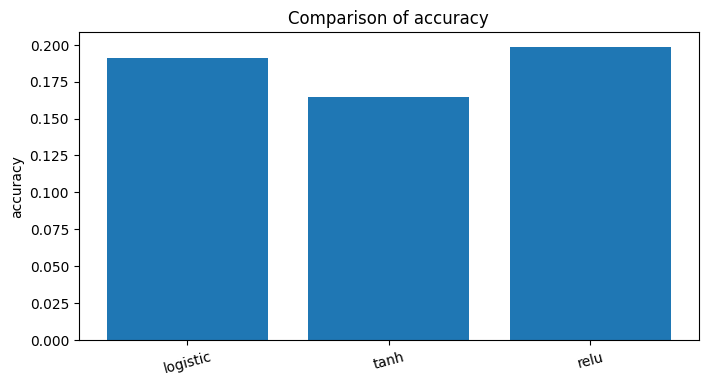

In [13]:
compare_models(
    names=results_df["activation"].tolist(),
    scores=results_df["accuracy"].tolist(),
    metric_name="accuracy"
)

Resposta: A ativação ReLU apresentou a melhor convergência, pois a obteve a maior accuracy entre as três ativações testadas. A ReLU também apresentou maior estabilidade. As métricas ficaram ligeiramente melhores e mais consistentes em comparação com logistic e tanh. Não houve diferenças muito grandes entre os resultados finais. As três ativações apresentaram desempenhos relativamente próximos, embora a ReLU tenha obtido os melhores valores. No CIFAR-100, o problema é bem mais difícil do que no CIFAR-10, porque agora são 100 classes. Então, uma accuracy em torno de 0.20 já está apenas um pouco acima do acaso, que seria 0.01. Isso mostra que a MLP conseguiu aprender alguma coisa, mas ainda com desempenho limitado. A ReLU é amplamente utilizada, pois ela é simples, eficiênte computacionalmente e reduz problemas de gradiente desaparecendo.

# Questão 6

Compare as seguintes arquiteturas:

```python
(32,)
(64,)
(128, 64)
(256, 128)
```

## Requisitos

Para cada arquitetura:

- treine;
- avalie;
- registre no MLflow.

Analise:

- accuracy;
- custo computacional;
- estabilidade;
- overfitting.

Responda:

1. Redes maiores sempre melhoraram os resultados?
2. Qual arquitetura apresentou melhor tradeoff?
3. Houve sinais de overfitting?
4. Qual arquitetura apresentou maior custo computacional?

**Solução**:

In [14]:
# TODO: implemente
import mlflow
import pandas as pd

from experiment import measure_training_time
from metrics import classification_metrics


def run_architecture_comparison(
    X_train,
    y_train,
    X_val,
    y_val,
    hidden_layers_list=((32,), (64,), (128, 64), (256, 128)),
    activation="relu",
    learning_rate=0.001,
    seed=42,
    max_iter=100,
    batch_size=32
):
    results = []

    for hidden_layers in hidden_layers_list:
        with mlflow.start_run(run_name=f"arch_{hidden_layers}"):
            # Parâmetros
            mlflow.log_param("activation", activation)
            mlflow.log_param("hidden_layers", str(hidden_layers))
            mlflow.log_param("learning_rate", learning_rate)
            mlflow.log_param("seed", seed)
            mlflow.log_param("max_iter", max_iter)
            mlflow.log_param("batch_size", batch_size)

            model, training_time = measure_training_time(
                train_mlp,
                X_train,
                y_train,
                activation,
                hidden_layers,
                learning_rate,
                seed,
                max_iter,
                batch_size
            )

            val_metrics, _ = evaluate(model, X_val, y_val)

            y_train_pred = model.predict(X_train)
            train_metrics = classification_metrics(y_train, y_train_pred)

            extra_metrics = {
                "training_time": training_time,
                "n_iter": model.n_iter_,
                "final_loss": model.loss_,
                "train_accuracy": train_metrics["accuracy"],
                "train_precision": train_metrics["precision"],
                "train_recall": train_metrics["recall"],
                "train_f1_score": train_metrics["f1_score"],
            }

            for metric_name, metric_value in val_metrics.items():
                mlflow.log_metric(metric_name, metric_value)

            for metric_name, metric_value in extra_metrics.items():
                mlflow.log_metric(metric_name, metric_value)

            if hasattr(model, "loss_curve_"):
                for epoch, loss in enumerate(model.loss_curve_):
                    mlflow.log_metric("loss", loss, step=epoch)

            row = {
                "hidden_layers": str(hidden_layers),
                **val_metrics,
                **extra_metrics
            }
            results.append(row)

    return pd.DataFrame(results)

In [15]:
results_df = run_architecture_comparison(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    hidden_layers_list=((32,), (64,), (128, 64), (256, 128)),
    activation="relu",
    learning_rate=0.001,
    seed=42,
    max_iter=100,
    batch_size=32
)

display(results_df)

,hidden_layers,accuracy,precision,recall,f1_score,training_time,n_iter,final_loss,train_accuracy,train_precision,train_recall,train_f1_score
0,"(32,)",0.0484,0.016498,0.0484,0.022422,188.188062,100,4.123807,0.05115,0.016952,0.05115,0.023100
1,"(64,)",0.0100,0.000100,0.0100,0.000198,65.031443,15,4.605940,0.01000,0.000100,0.01000,0.000198
2,"(128, 64)",0.1987,0.196191,0.1987,0.184900,1319.782757,100,2.972851,0.26905,0.277288,0.26905,0.254937
3,"(256, 128)",0.1952,0.192357,0.1952,0.184223,2617.432139,100,2.704241,0.32540,0.337983,0.32540,0.316238


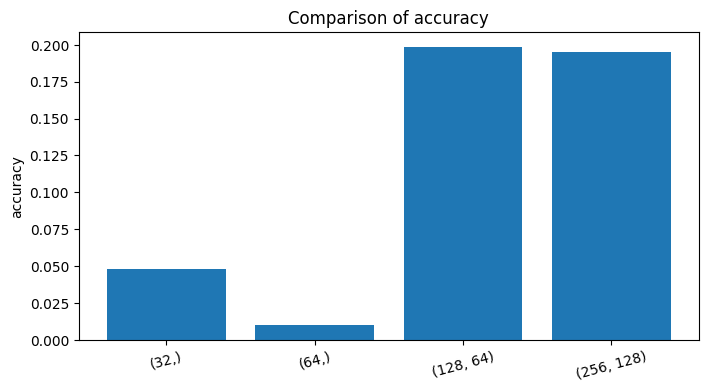

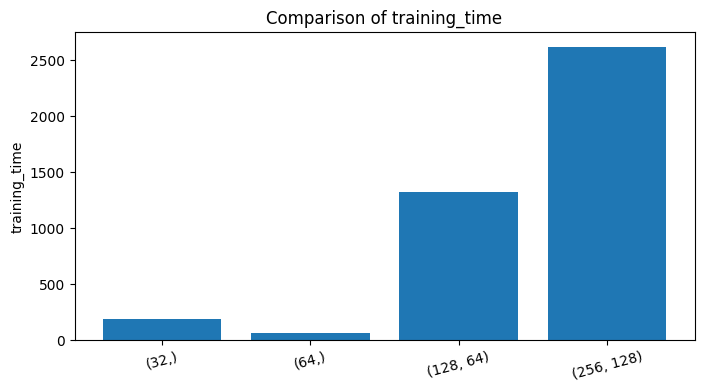

In [16]:
compare_models(
    names=results_df["hidden_layers"].tolist(),
    scores=results_df["accuracy"].tolist(),
    metric_name="accuracy"
)

compare_models(
    names=results_df["hidden_layers"].tolist(),
    scores=results_df["training_time"].tolist(),
    metric_name="training_time"
)

Resposta: Não. O aumento de tamanho ajudou em parte, mas não de forma monotônica. A arquitetura (64,) teve desempenho muito ruim, e embora (128, 64) e (256, 128) tenham sido melhores, o ganho da maior rede sobre (128, 64) foi mínimo. A arquitetura que apresentou melhor tradeoff foi a (128, 64), pois conseguiu desempenho melhor que (256, 128) em um tempo muito menor. Sim, houve sinais de overfitting, em especial, para as arquiteturas maiores. O desempenho de treino foi bem melhor do que o de teste. A arquitetura (256, 128) foi a que apresentou maior custo computacional.

# Questão 7

Compare os seguintes learning rates:

```python
0.1
0.01
0.001
```

## Requisitos

Utilize:

- mesma arquitetura;
- mesma ativação;
- mesma seed.

Para cada experimento:

- treine;
- avalie;
- registre no MLflow.

Analise:

- estabilidade;
- convergência;
- accuracy;
- comportamento da loss.

Responda:

1. Qual learning rate apresentou melhor desempenho?
2. Qual apresentou maior instabilidade?
3. O que acontece quando o learning rate é muito alto?
4. O que acontece quando o learning rate é muito baixo?

In [17]:
# TODO: implemente
def run_learning_rate_comparison(
    X_train,
    y_train,
    X_val,
    y_val,
    hidden_layers=(128, 64),
    activation="relu",
    seed=42,
    max_iter=100,
    batch_size=32,
    learning_rates=(0.1, 0.01, 0.001)
):
    results = []

    for learning_rate in learning_rates:
        with mlflow.start_run(run_name=f"lr_{learning_rate}"):
            # Parâmetros
            mlflow.log_param("activation", activation)
            mlflow.log_param("hidden_layers", str(hidden_layers))
            mlflow.log_param("learning_rate", learning_rate)
            mlflow.log_param("seed", seed)
            mlflow.log_param("max_iter", max_iter)
            mlflow.log_param("batch_size", batch_size)

            model, training_time = measure_training_time(
                train_mlp,
                X_train,
                y_train,
                activation,
                hidden_layers,
                learning_rate,
                seed,
                max_iter,
                batch_size
            )

            val_metrics, _ = evaluate(model, X_val, y_val)

            y_train_pred = model.predict(X_train)
            train_metrics = classification_metrics(y_train, y_train_pred)

            extra_metrics = {
                "training_time": training_time,
                "n_iter": model.n_iter_,
                "final_loss": model.loss_,
                "train_accuracy": train_metrics["accuracy"],
                "train_precision": train_metrics["precision"],
                "train_recall": train_metrics["recall"],
                "train_f1_score": train_metrics["f1_score"],
            }

            for metric_name, metric_value in val_metrics.items():
                mlflow.log_metric(metric_name, metric_value)

            for metric_name, metric_value in extra_metrics.items():
                mlflow.log_metric(metric_name, metric_value)

            if hasattr(model, "loss_curve_"):
                for epoch, loss in enumerate(model.loss_curve_):
                    mlflow.log_metric("loss", loss, step=epoch)

            row = {
                "learning_rate": learning_rate,
                **val_metrics,
                **extra_metrics
            }
            results.append(row)

    return pd.DataFrame(results)

In [18]:
results_lr_df = run_learning_rate_comparison(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    hidden_layers=(128, 64),
    activation="relu",
    seed=42,
    max_iter=100,
    batch_size=32,
    learning_rates=(0.1, 0.01, 0.001)
)

display(results_lr_df)

,learning_rate,accuracy,precision,recall,f1_score,training_time,n_iter,final_loss,train_accuracy,train_precision,train_recall,train_f1_score
0,0.100,0.0100,0.000100,0.0100,0.000198,251.430299,20,4.649488,0.01000,0.000100,0.01000,0.000198
1,0.010,0.0100,0.000100,0.0100,0.000198,484.717753,38,4.610630,0.01000,0.000100,0.01000,0.000198
2,0.001,0.1987,0.196191,0.1987,0.184900,1252.628816,100,2.972851,0.26905,0.277288,0.26905,0.254937


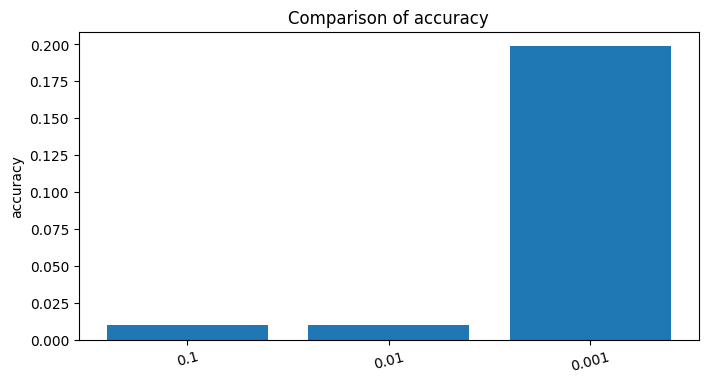

In [19]:
compare_models(
    names=results_lr_df["learning_rate"].astype(str).tolist(),
    scores=results_lr_df["accuracy"].tolist(),
    metric_name="accuracy"
)

Resposta: O learning rate de 0.001 apresentou o melhor desempenho, com melhor accuracy e menor loss final. O learning rate de 0.1 e 0.01 se mostram os mais instáveis, porque tiveram desempenho mais fraco. Quando o learning rate é muito alto, o modelo dá passos grandes demais na atualização dos pesos. Isso pode fazer ele pular bons mínimos e não convergir direito. Com um learning rate muito baixo, o modelo aprende de forma mais lenta, demora mais para convergir, mas obtém resultados melhores.

# Questão 8

Com base nos experimentos realizados, escreva uma discussão contendo:

- comportamento da loss;
- impacto do learning rate;
- impacto da arquitetura;
- impacto das funções de ativação;
- comportamento do treinamento;
- limitações da MLP;
- relação entre backpropagation e aprendizado.

Além disso, responda:

1. Qual configuração apresentou melhor resultado final?
2. Quais foram as principais dificuldades observadas?
3. Por que MLPs possuem limitações para imagens?
4. Como o backpropagation contribui para o aprendizado da rede?

Resposta: Os experimentos com CIFAR-100 mostraram que a loss só diminuiu de forma relevante nas configurações mais adequadas, principalmente com learning rate = 0.001 e arquiteturas maiores. Taxas muito altas, como 0.1 e 0.01, levaram o modelo a desempenho quase aleatório, enquanto a ReLU foi a melhor ativação, embora com diferença pequena em relação às outras. Redes menores subajustaram, e redes maiores melhoraram a accuracy, mas com maior custo computacional e sinais de overfitting. Isso evidencia as limitações da MLP para imagens: ao aplicar flatten, ela perde a estrutura espacial dos pixels e não explora padrões visuais locais. Assim, o backpropagation só conseguiu produzir bom aprendizado quando os hiperparâmetros permitiram atualizações estáveis e a rede tinha capacidade suficiente para representar o problema. A melhor configuração foi a que combinou learning_rate = 0.001, activation = relu e a arquitetura (128, 64). Os principais problemas foram o baixo desempenho do modelo perante um alto custo computacional e tempo de treinamento. O backpropagation calcula como cada peso contribui para o erro e ajusta os parâmetros para reduzir a loss